# MGSC 661 - Predicting Movie Opening-Weekend Revenue


 

## Setup

In [3]:
%pip install ISLP

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 5.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 8.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.4 MB/s  0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4118 sha256=85887707bbf4b86e475554f5d936275964b31501021cfe1c1d671733073e37b7
  Stored in directory: /Users/katherine/Library/Caches/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [ISLP]2m11/12 [ISLP]ch_lightning]
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro

from ISLP.models import (ModelSpec as MS,
                         summarize)

In [6]:
df = pd.read_excel("movie_training_data_student.xlsx", sheet_name="Training_Data")
df.head()

,movie_id,title,release_date,release_year,release_month,release_quarter,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,...,holiday_release,source_dataset,source_url,audience_score,domestic_box_office_musd,foreign_box_office_musd,worldwide_box_office_musd,opening_revenue_per_theater_kusd,opening_budget_recovery_pct,worldwide_budget_recovery_pct
0,TRN-0001,Escape Room,2019-01-04,2019,1,Q1,18.238172,9.0,2717,109.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Escape-Room-...,54.0,57.00,98.61,155.62,6.712614,2.026464,17.291111
1,TRN-0002,A Dog’s Way Home,2019-01-11,2019,1,Q1,11.251263,61.0,3090,102.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Dogs-Way-Hom...,71.0,41.95,39.20,81.15,3.641185,0.184447,1.330328
2,TRN-0003,Replicas,2019-01-11,2019,1,Q1,2.375325,30.0,2329,107.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Replicas-(2018),NaN,NaN,NaN,NaN,1.019891,0.079177,NaN
3,TRN-0004,Dragon Ball Super: Broly,2019-01-16,2019,1,Q1,9.816197,8.5,1247,100.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Dragon-Ball-...,NaN,NaN,NaN,NaN,7.871850,1.154847,NaN
4,TRN-0005,Glass,2019-01-18,2019,1,Q1,40.328920,20.0,3841,128.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Glass-(2019),66.0,111.05,135.95,247.00,10.499589,2.016446,12.350000


# Part 1. Conduct an initial assessment of the data

## Question 1. Report the number of observations and variables

In [7]:
n_observations, n_variables = df.shape

print("Number of observations:", n_observations)
print("Number of variables:", n_variables)

Number of observations: 359
Number of variables: 29


The Training_Data dataset contains 359 observations and 29 variables.

## Question 2. Create a missing-value report

In [8]:
missing_number_by_column = df.isna().sum()
missing_percentage_by_column = df.isna().mean() * 100

missing_report = pd.DataFrame({
    "Missing number": missing_number_by_column,
    "Missing percentage": missing_percentage_by_column
}).round(2)

missing_report

,Missing number,Missing percentage
movie_id,0,0.00
title,0,0.00
release_date,0,0.00
release_year,0,0.00
release_month,0,0.00
release_quarter,0,0.00
opening_weekend_revenue_musd,0,0.00
production_budget_musd,0,0.00
opening_theaters,0,0.00
runtime_minutes,5,1.39


## Question 3. Report descriptive statistics for the numerical variables

In [9]:
numerical_variables = df.select_dtypes(include=np.number).columns

# Use .describe(), as in the introductory Python lab. Pandas ignores missing
# observations separately for each variable.
summary = df[numerical_variables].describe().T

descriptive_statistics = pd.DataFrame({
    "Range": summary["max"] - summary["min"],
    "Mean": summary["mean"],
    "Min": summary["min"],
    "Max": summary["max"]
}).round(3)

descriptive_statistics.index.name = "Variable"
descriptive_statistics

,Range,Mean,Min,Max
Variable,,,,
release_year,6.000,2022.432,2019.000,2025.000
release_month,11.000,6.735,1.000,12.000
opening_weekend_revenue_musd,356.864,29.555,0.251,357.115
production_budget_musd,399.985,67.761,0.015,400.000
opening_theaters,4075.000,3211.900,660.000,4735.000
runtime_minutes,113.000,115.384,84.000,197.000
summer_release,1.000,0.248,0.000,1.000
holiday_release,1.000,0.187,0.000,1.000
audience_score,68.000,79.460,31.000,99.000


# Part 2. Estimate and interpret the baseline model

## Question 4. Prepare the baseline-model sample

In [10]:
baseline_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

# Drop rows only when a variable required by this model is missing.
baseline_data = df[baseline_variables].dropna().copy()

In [11]:
baseline_sample_size = len(baseline_data)
observations_removed = len(df) - baseline_sample_size

print("Baseline sample size:", baseline_sample_size)
print("Observations removed:", observations_removed)

Baseline sample size: 354
Observations removed: 5


After dropping observations with missing values in the outcome or the three baseline predictors, there are 354 observations remained and 5 observations removed.

## Question 5. Estimate and report the full baseline model

In [12]:
baseline_predictors = [
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

design_baseline = MS(baseline_predictors)
X_baseline = design_baseline.fit_transform(baseline_data)
y_baseline = baseline_data["opening_weekend_revenue_musd"]

baseline_model = sm.OLS(y_baseline, X_baseline)
baseline_results = baseline_model.fit()

In [13]:
summarize(baseline_results)

,coef,std err,t,P>|t|
intercept,-48.7159,11.848,-4.112,0.000
production_budget_musd,0.2760,0.030,9.116,0.000
opening_theaters,0.0142,0.002,6.448,0.000
runtime_minutes,0.1242,0.086,1.439,0.151


In [14]:
print("R-squared:", baseline_results.rsquared)
print("Residual standard error:", np.sqrt(baseline_results.mse_resid))

R-squared: 0.5263363838727473
Residual standard error: 28.76510421198774


The R² of the baseline regression model is 0.526, indicating that the model explains approximately 52.6% of the variance in opening-weekend box office revenue. The standard error of the residuals is $28.765 million, meaning that a typical prediction error is approximately $28.8 million. At the 5% significance level, production budget and the number of theaters screening the film during its opening weekend are statistically significant predictors, while runtime is not statistically significant.

## Question 6. Interpret all coefficients in the baseline model

Holding all other predictors in the model constant, a $1 million increase in production budget is associated with an average increase of $276,000 in opening weekend box office revenue. An increase of one in the number of theaters showing the film on opening weekend is associated with an average increase of $14,200 in opening weekend box office revenue. For every 1-minute increase in runtime, opening weekend box office revenue increases by an average of $124,200. The intercept is -$48.716 million, representing the predicted opening weekend box office revenue when all three predictor variables are zero. But this scenario has no practical significance.

## Question 7. Remove insignificant predictors and re-estimate the model

In [15]:
# Keep predictors with p-values below 0.05 in the full baseline model.
p_values = baseline_results.pvalues.drop("intercept")
significant_predictors = p_values[p_values < 0.05].index.tolist()

significant_predictors

['production_budget_musd', 'opening_theaters']

In [16]:
 #=======regression with significant predictors only=======
design_reduced = MS(significant_predictors)

X_reduced = design_reduced.fit_transform(baseline_data)

reduced_model = sm.OLS(y_baseline, X_reduced)

reduced_results = reduced_model.fit()

In [17]:
summarize(reduced_results)

,coef,std err,t,P>|t|
intercept,-34.2288,6.255,-5.472,0.0
production_budget_musd,0.2970,0.027,11.178,0.0
opening_theaters,0.0137,0.002,6.291,0.0


In [18]:
print("Full model R-squared:", baseline_results.rsquared)
print("Reduced model R-squared:", reduced_results.rsquared)

print("Full model residual standard error:",
      np.sqrt(baseline_results.mse_resid))

print("Reduced model residual standard error:",
      np.sqrt(reduced_results.mse_resid))

Full model R-squared: 0.5263363838727473
Reduced model R-squared: 0.5235344822437069
Full model residual standard error: 28.76510421198774
Reduced model residual standard error: 28.80893080656709


The simplified model excluded the run time variable because its p-value in the full baseline model was 0.151, exceeding the 5% significance level. The R² of the simplified model is 0.523, while that of the full model is 0.526. Its standard error of residuals is $28.809 million, compared to $28.765 million for the full model. Therefore, excluding runtime resulted in a slight decrease in R² and a slight increase in the standard error of the residuals. In addition, after excluding this variable, the coefficients for production budget and number of premiere theaters also changed slightly.

# Part 3. Assess the baseline model and its assumptions

## Question 8. Assess linearity using a residual-versus-fitted plot

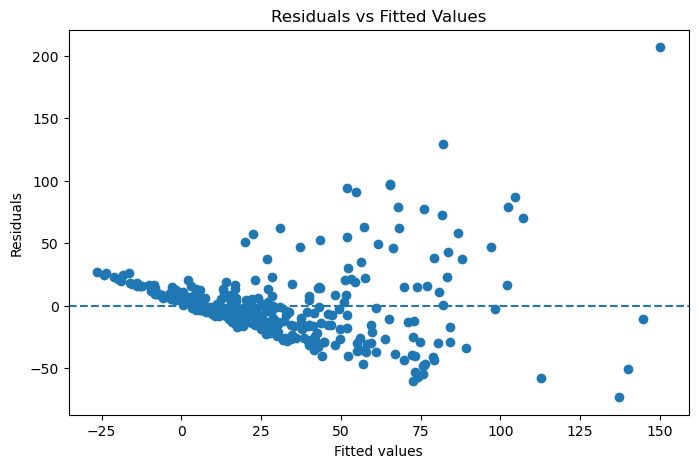

In [19]:
#plot the residual vs predicted value graph
fitted_values = baseline_results.fittedvalues
residuals = baseline_results.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

The residual-versus-fitted plot reveals a systematic pattern rather than residuals randomly distributed around zero. Specifically, the residuals show a downward trend when the fitted values are low, while they exhibit greater dispersion when the fitted values are high. This suggests that the linearity assumption may not be fully satisfied.

## Question 9. Calculate and interpret the Durbin-Watson statistic

In [22]:
# Put residuals in release-date order before calculating the DW statistic.
dw_df = df.loc[baseline_data.index, ["release_date"]].copy()

dw_df["residual"] = baseline_results.resid.to_numpy()

dw_df = dw_df.sort_values("release_date").reset_index(drop=True)

dw_statistic = durbin_watson(dw_df["residual"])

print("Durbin-Watson statistic (release-date order):", round(dw_statistic, 4))

Durbin-Watson statistic (release-date order): 1.9864


The Durbin-Watson statistic is 1.9864, which is very close to 2. This indicates that, when the observations are sorted by release date, there is almost no evidence of autocorrelation in the residuals.

## Question 10. Assess constant error variance using White's test

In [23]:
white_test = het_white(baseline_results.resid, X_baseline)

white_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]

white_results = pd.Series(white_test, index=white_labels)

white_results

LM statistic    1.297007e+02
LM p-value      1.366475e-23
F statistic     2.210194e+01
F p-value       1.518326e-29
dtype: float64

Both the p-value for the LM test and the p-value for the F-test in the White test are less than 0.001. Therefore, at the 5% significance level, we reject the null hypothesis that the error variance is constant. This strongly suggests that the error variance is not constant.

## Question 11. Assess normality using a Q-Q plot and the Shapiro-Wilk test

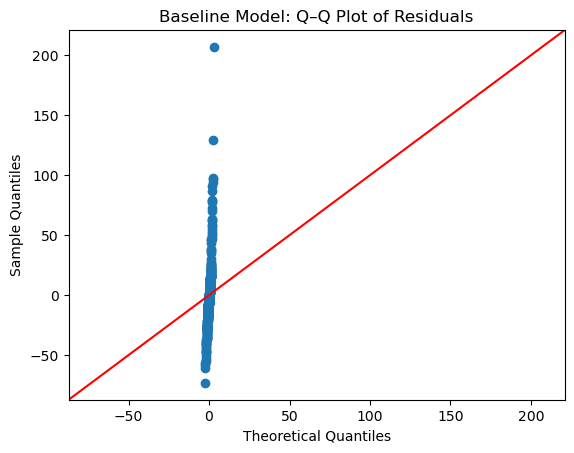

Shapiro-Wilk statistic: 0.859669666288766
Shapiro-Wilk p-value: 2.4937854556837257e-17


In [24]:
sm.qqplot(baseline_results.resid, line="45")
plt.title("Baseline Model: Q–Q Plot of Residuals")
plt.show()

shapiro_result = shapiro(baseline_results.resid)

print("Shapiro-Wilk statistic:", shapiro_result.statistic)
print("Shapiro-Wilk p-value:", shapiro_result.pvalue)

The Q-Q plot shows that the residuals deviate significantly from the 45-degree reference line, particularly at the tails of the distribution. The p-value from the Shapiro-Wilk test is 2.4937854556837257e-17, which is below the 5% significance level. Therefore, we reject the null hypothesis that the residuals follow a normal distribution. These results indicate that the residuals do not follow a normal distribution.

## Question 12. Identify high-leverage and influential observations

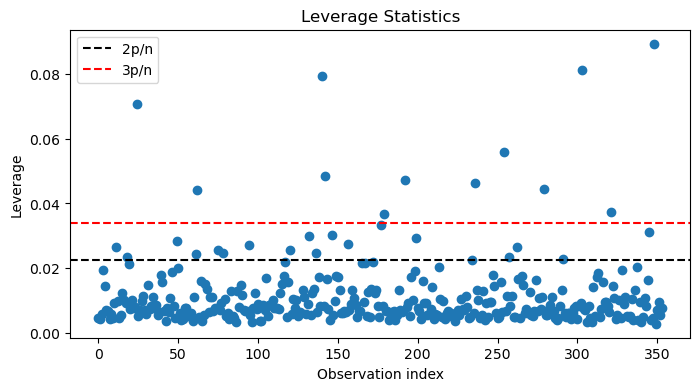

2p/n threshold: 0.0226
3p/n threshold: 0.0339
Movies above 2p/n: 30
Movies above 3p/n: 12


In [27]:
# Leverage statistics, following the lecture.
influence = baseline_results.get_influence()
leverage = influence.hat_matrix_diag

n = len(baseline_data)
p = len(baseline_predictors) + 1

leverage_2pn = 2 * p / n
leverage_3pn = 3 * p / n

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(np.arange(n), leverage)
ax.axhline(leverage_2pn, color="black", linestyle="--", label="2p/n")
ax.axhline(leverage_3pn, color="red", linestyle="--", label="3p/n")
ax.set_xlabel("Observation index")
ax.set_ylabel("Leverage")
ax.set_title("Leverage Statistics")
ax.legend()
plt.show()

print("2p/n threshold:", round(leverage_2pn, 4))
print("3p/n threshold:", round(leverage_3pn, 4))
print("Movies above 2p/n:", int((leverage > leverage_2pn).sum()))
print("Movies above 3p/n:", int((leverage > leverage_3pn).sum()))

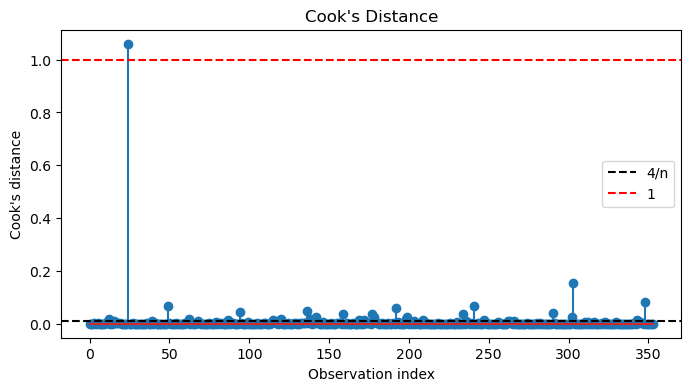

Movies with leverage above 3p/n:


,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
353,89.1609,400.0,3800,197.0,0.0894,0.0839
308,64.0364,400.0,3857,169.0,0.0812,0.1559
143,134.1002,400.0,4202,190.0,0.0795,0.0032
24,357.1150,400.0,4662,181.0,0.0708,1.0604
259,5.6000,75.0,1040,178.0,0.0560,0.0002
145,3.6034,80.0,3343,188.0,0.0484,0.0264
196,93.2248,15.0,3855,168.0,0.0474,0.0614
241,11.0526,50.0,3334,181.0,0.0464,0.0087
284,7.2000,80.0,660,143.0,0.0446,0.0007
62,91.0622,70.0,4570,169.0,0.0441,0.0176


Movies with Cook's distance above 4/n:


,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
24,357.1150,400.0,4662,181.0,0.0708,1.0604
308,64.0364,400.0,3857,169.0,0.0812,0.1559
353,89.1609,400.0,3800,197.0,0.0894,0.0839
49,191.7708,260.0,4725,118.0,0.0283,0.0688
246,211.4353,200.0,4210,127.0,0.0128,0.0668
196,93.2248,15.0,3855,168.0,0.0474,0.0614
139,181.3398,250.0,4396,161.0,0.0246,0.0485
94,177.3839,275.0,4406,142.0,0.0270,0.0425
295,162.7530,150.0,4263,100.0,0.0134,0.0394
239,154.2017,200.0,4440,100.0,0.0226,0.0374


Movies with Cook's distance above 1:


,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
24,357.115,400.0,4662,181.0,0.0708,1.0604


In [30]:
# Cook's distance, following the lecture.
ols_influence = OLSInfluence(baseline_results)
cooks_distance, cooks_pvalue = ols_influence.cooks_distance
cook_threshold = 4 / n

fig, ax = subplots(figsize=(8, 4))
ax.stem(np.arange(n), cooks_distance)
ax.axhline(cook_threshold, color="black", linestyle="--", label="4/n")
ax.axhline(1, color="red", linestyle="--", label="1")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance")
ax.legend()
plt.show()

influence_table = baseline_data[[
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]].copy()

influence_table["Leverage"] = leverage
influence_table["Cook's distance"] = cooks_distance

very_high_leverage = influence_table[
    influence_table["Leverage"] > leverage_3pn
].sort_values("Leverage", ascending=False)

large_cook = influence_table[
    influence_table["Cook's distance"] > cook_threshold
].sort_values("Cook's distance", ascending=False)

serious_cook = influence_table[
    influence_table["Cook's distance"] > 1
].sort_values("Cook's distance", ascending=False)

print("Movies with leverage above 3p/n:")
display(very_high_leverage.round(4))

print("Movies with Cook's distance above 4/n:")
display(large_cook.round(4))

print("Movies with Cook's distance above 1:")
display(serious_cook.round(4))

The leverage thresholds are 0.0226 for 2p/n and 0.0339 for 3p/n. There are 30 observations above the 2p/n threshold and 12 above the 3p/n threshold, indicating that several observations have relatively high leverage. Cook’s distance identifies several potentially influential observations above 4/n. Observation 24 is the most serious case, with leverage of 0.0708 and Cook’s distance of 1.0604, exceeding the reference value of 1. Other observations, including 308 and 353, have relatively high leverage, although their Cook’s distances are below 1. This suggests that high leverage does not necessarily imply strong influence on the fitted regression. Overall, the baseline model has important weaknesses: some observations have unusually high leverage or influence, and the diagnostic results from the previous questions indicate that the model assumptions are not fully satisfied. Therefore, the baseline regression should be interpreted cautiously, particularly when making predictions for observations that differ substantially from the typical movies in the sample.

# Part 4. Design your own regression model

## Question 13. State Y and the candidate X variables before fitting models

## Question 14. Write and justify the final regression model

## Question 15. Describe and report the missing-value treatment

## Question 16. Create and display the y vector and X matrix

## Question 17. Estimate, report, and interpret the final model

## Question 18. Evaluate limitations and training-data prediction accuracy

# Part 5. Reflect on the use of AI